   No  X1 transaction date  X2 house age  \
0   1          2012.916667          32.0   
1   2          2012.916667          19.5   
2   3          2013.583333          13.3   
3   4          2013.500000          13.3   
4   5          2012.833333           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3     24.98746     121.54391  

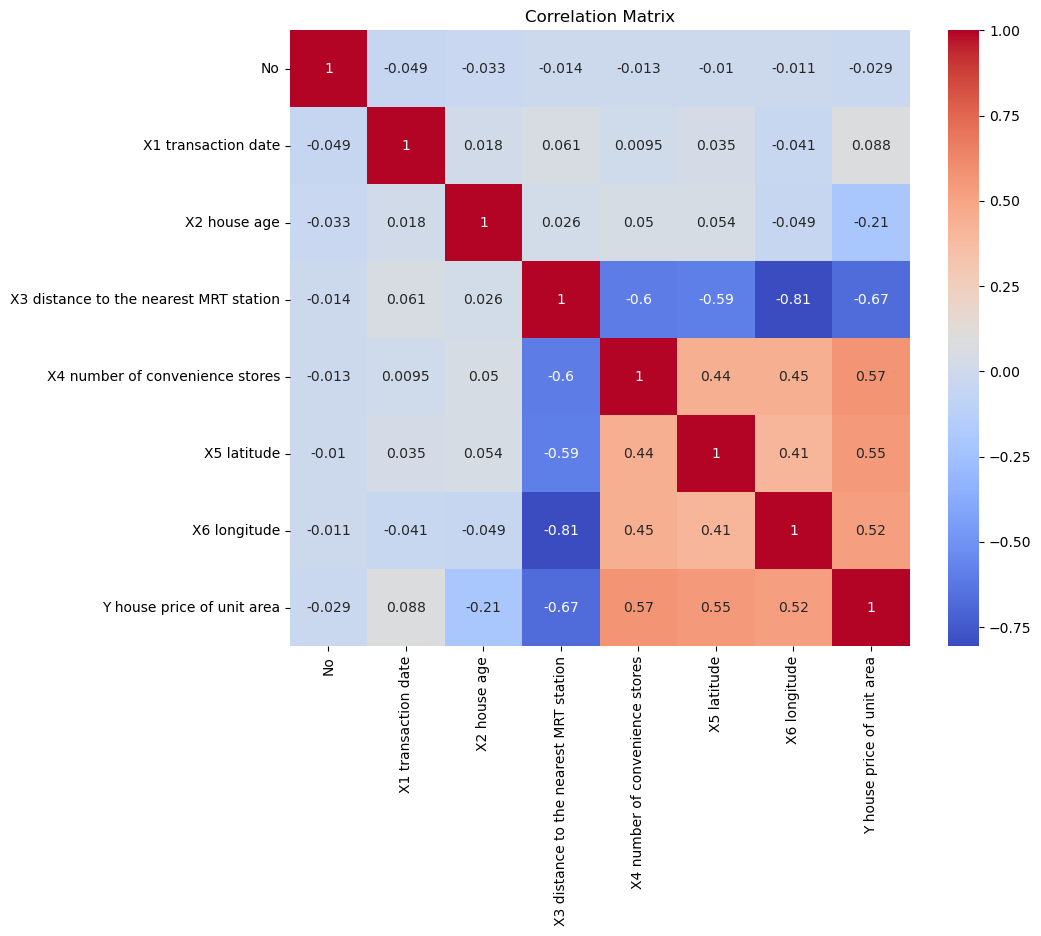

   Model       MAE      RMSE        R2
0    OLS  5.418033  7.389103  0.674541
1  Ridge  5.414440  7.384880  0.674913
2  Lasso  5.395214  7.347307  0.678213
3    SVR  5.786838  7.903483  0.627652
OLS CV RMSE: 8.8040
Ridge CV RMSE: 8.8028
Lasso CV RMSE: 8.7875
SVR CV RMSE: 8.9926


In [3]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA
df = pd.read_excel("Real estate valuation data set.xlsx")

# Xem dữ liệu
print(df.head())
print(df.describe())

# 3. DEFINE FEATURES & TARGET
X = df.drop(columns=["Y house price of unit area"])
y = df["Y house price of unit area"]

# 4. CORRELATION MATRIX (cho report)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 5. NORMALIZATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 7. DEFINE MODELS
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "SVR": SVR(kernel='rbf')
}

# 8. TRAIN & EVALUATE
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])

# 9. SHOW RESULTS TABLE
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
print(results_df)

# 10. K-FOLD CROSS VALIDATION (optional nhưng nên có)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, scoring='neg_mean_squared_error', cv=kf)
    rmse_scores = np.sqrt(-scores)
    print(f"{name} CV RMSE: {rmse_scores.mean():.4f}")